# NB2 — Temperature, Top-K & Top-P Sampling
### Session 04 · M01 Foundation — Modern LLM Internals

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nursnaaz/zero-to-genai-engineer/blob/main/04_BPE_Temperature_Top_K_Top_P/notebooks/NB2_Temperature_TopK_TopP.ipynb)

---

**The central question this notebook answers:**

> After NB1, you know how words become token IDs.  
> Now: the model has computed a probability over every token in its vocabulary.  
> *How does it decide which token to actually pick?*

The answer involves three mechanisms you will control in every LLM API call you ever make:

| Parameter | Controls |
|---|---|
| **Temperature** | How peaked vs flat the probability distribution is |
| **Top-K** | Only consider the K most probable tokens |
| **Top-P** (nucleus) | Only consider tokens that together account for P% of probability mass |

---

**What you will build:**
- The math behind softmax and temperature (with plots)
- `apply_temperature()`, `top_k_filter()`, `top_p_filter()` from scratch
- A live Gemini API experiment comparing coherence vs creativity
- A complete `sample_token()` function combining all three in the correct order

**API key required:** Set your `GEMINI_API_KEY` in the next cell.

---

**Four sections:**
| Section | What you do |
|---|---|
| 1 — Concept | Understand the math. Run all cells. |
| 2 — Guided Build | Fill in `___` to implement the three sampling functions. |
| 3 — Experiment | Call Gemini API at different temperatures and observe the difference. |
| 4 — Challenge | Build a full `sample_token()` that chains all three in the right order. |

In [1]:
# Install required libraries
# google-generativeai : the Gemini API client
# matplotlib          : for visualising probability distributions
# numpy               : for softmax math and array operations
!pip install google-generativeai matplotlib numpy --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 5.29.6 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os

# === API KEY SETUP ===
# Option 1 (recommended for Colab): store the key as a Colab Secret
#   Go to the key icon (🔑) in the left sidebar → Add secret → Name: GEMINI_API_KEY
#   Then run this cell — it will load automatically

# Option 2: paste your key directly (not recommended — never commit keys to git)
#   GEMINI_API_KEY = "your-key-here"
#   os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

try:
    # Try to load from Colab Secrets first
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    os.environ['GEMINI_API_KEY'] = GEMINI_API_KEY
    print("Loaded GEMINI_API_KEY from Colab Secrets.")
except Exception:
    # Fall back to environment variable (for local Jupyter runs)
    GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY', '')
    if GEMINI_API_KEY:
        print("Loaded GEMINI_API_KEY from environment variable.")
    else:
        print("WARNING: GEMINI_API_KEY not found.")
        print("Section 3 (Gemini API experiments) will be skipped.")
        print("Sections 1, 2, and 4 work without an API key.")

Loaded GEMINI_API_KEY from environment variable.


---
## SECTION 1 — CONCEPT
### How LLMs generate text: logits → softmax → sampling

> Run every cell in this section. Nothing to fill in — just read, run, and understand.

### 1.1 — What are logits?

When a Transformer processes a sequence of tokens, its final layer outputs a vector of raw scores — one score per token in the vocabulary. These raw scores are called **logits**.

**Analogy:** Imagine a judge at a baking competition rating 50,000 cakes. The judge gives each cake a raw score (can be negative, can be very large — no constraint). To decide the winner, you need to convert those raw scores into a probability distribution over all cakes.

That conversion is **softmax**.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- The softmax function ---
# softmax(z)[i] = exp(z[i]) / sum(exp(z[j]) for all j)
# 
# Properties:
#   - Output is always between 0 and 1
#   - Outputs sum to exactly 1 (a valid probability distribution)
#   - Larger logit → higher probability (the ordering is preserved)

def softmax(logits):
    """Convert raw logit scores into a probability distribution."""
    # Subtract the maximum for numerical stability
    # (prevents exp() from overflowing for large positive logits)
    logits_stable = logits - np.max(logits)
    exp_logits = np.exp(logits_stable)     # apply exp to each logit
    return exp_logits / exp_logits.sum()   # divide by sum so they add to 1


# A toy example: 8 tokens with raw logit scores
# (In reality, there would be 50,000+ tokens)
tokens = ['the', 'a', 'cat', 'dog', 'sat', 'ran', 'blue', 'jumped']
logits = np.array([4.2, 3.1, 2.8, 1.5, 0.9, 0.3, -0.5, -1.2])

probs = softmax(logits)

print("=== Logits → Probabilities ===")
print()
print(f"{'Token':<10} {'Logit':>8} {'Probability':>12}")
print("-" * 35)
for token, logit, prob in zip(tokens, logits, probs):
    bar = '█' * int(prob * 40)   # visual bar proportional to probability
    print(f"{token:<10} {logit:>8.1f} {prob:>11.4f}  {bar}")
print()
print(f"Sum of probabilities: {probs.sum():.6f} (must be exactly 1.0)")

=== Logits → Probabilities ===

Token         Logit  Probability
-----------------------------------
the             4.2      0.5823  ███████████████████████
a               3.1      0.1938  ███████
cat             2.8      0.1436  █████
dog             1.5      0.0391  █
sat             0.9      0.0215  
ran             0.3      0.0118  
blue           -0.5      0.0053  
jumped         -1.2      0.0026  

Sum of probabilities: 1.000000 (must be exactly 1.0)


### 1.2 — Temperature: controlling the sharpness of the distribution

**Analogy:** Think of temperature in terms of a water bowl.
- **Cold water (low T):** A ball placed in the bowl rolls immediately to the lowest point and stays there. Deterministic.
- **Hot, bubbling water (high T):** The ball bounces around randomly, visiting many positions. Unpredictable.

**The math:**
Instead of computing `softmax(logits)`, we compute `softmax(logits / T)`.

- When T < 1: dividing makes large logits even larger relative to small ones → distribution sharpens → model is more "confident"
- When T = 1: no change, normal softmax
- When T > 1: dividing shrinks all logits toward zero → distribution flattens → model is more "creative" (or confused)

In [4]:
def softmax_with_temperature(logits, temperature):
    """Apply temperature scaling before softmax.
    
    Args:
        logits:      numpy array of raw logit scores
        temperature: float, must be > 0
                     < 1 → sharper (more confident)
                     = 1 → standard softmax (no change)
                     > 1 → flatter (more random)
    """
    if temperature <= 0:
        raise ValueError("Temperature must be positive")
    
    # Divide logits by temperature BEFORE applying softmax
    scaled_logits = logits / temperature
    
    # Then apply standard softmax
    return softmax(scaled_logits)


# Use our toy example from above
temperatures = [0.1, 0.5, 1.0, 1.5, 2.0]

print("=== Effect of temperature on probability distribution ===")
print()
print(f"{'Token':<8}", end="")
for T in temperatures:
    print(f"  T={T:.1f}", end="")
print()
print("-" * 60)

for i, token in enumerate(tokens):
    print(f"{token:<8}", end="")
    for T in temperatures:
        p = softmax_with_temperature(logits, T)[i]
        print(f"  {p:.4f}", end="")
    print()

print()
print("Observation:")
print("  T=0.1: 'the' captures almost all probability — nearly greedy")
print("  T=2.0: probabilities are more evenly spread — more variety in output")

=== Effect of temperature on probability distribution ===

Token     T=0.1  T=0.5  T=1.0  T=1.5  T=2.0
------------------------------------------------------------
the       1.0000  0.8489  0.5823  0.4358  0.3534
a         0.0000  0.0941  0.1938  0.2093  0.2039
cat       0.0000  0.0516  0.1436  0.1714  0.1755
dog       0.0000  0.0038  0.0391  0.0720  0.0916
sat       0.0000  0.0012  0.0215  0.0483  0.0679
ran       0.0000  0.0003  0.0118  0.0324  0.0503
blue      0.0000  0.0001  0.0053  0.0190  0.0337
jumped    0.0000  0.0000  0.0026  0.0119  0.0238

Observation:
  T=0.1: 'the' captures almost all probability — nearly greedy
  T=2.0: probabilities are more evenly spread — more variety in output


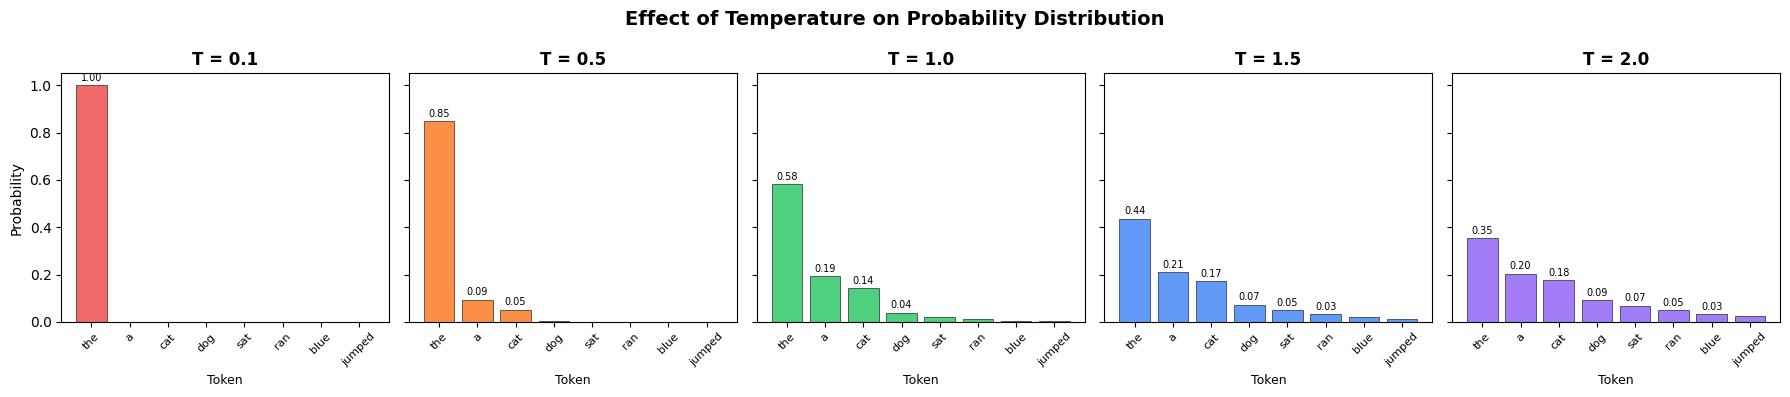

Saved: temperature_comparison.png


In [5]:
# === Visualise temperature effects ===

fig, axes = plt.subplots(1, len(temperatures), figsize=(18, 4), sharey=True)
fig.suptitle('Effect of Temperature on Probability Distribution', fontsize=14, fontweight='bold')

colors = ['#ef4444', '#f97316', '#22c55e', '#3b82f6', '#8b5cf6']  # red to purple

for ax, T, color in zip(axes, temperatures, colors):
    probs_T = softmax_with_temperature(logits, T)
    
    # Draw a bar for each token
    bars = ax.bar(tokens, probs_T, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    ax.set_title(f'T = {T}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Token', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_ylim(0, 1.05)  # y-axis from 0 to 1
    
    # Add probability value on top of each bar
    for bar, prob in zip(bars, probs_T):
        if prob > 0.03:  # only label bars that are visible
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{prob:.2f}',
                ha='center', va='bottom', fontsize=7
            )
    
    # Label y-axis only on the leftmost chart
    if ax == axes[0]:
        ax.set_ylabel('Probability', fontsize=10)

plt.tight_layout()
plt.savefig('temperature_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: temperature_comparison.png")

### 1.3 — Top-K sampling: only consider the K most likely tokens

**Analogy:** You're at a restaurant with 200 items on the menu, but you're in a hurry. You only look at the 5 most popular dishes (Top-5). You ignore the rest — even if some of them might be great.

**The mechanic:**
1. Sort all tokens by probability (highest first)
2. Keep only the top K tokens
3. Set all other tokens' probabilities to 0
4. Re-normalise so the remaining K tokens' probabilities sum to 1
5. Sample from these K tokens

**Typical values:** K = 40–50 for general use. K = 1 is greedy decoding (always pick the best token).

In [6]:
def top_k_filter(probs, k):
    """Zero out all probabilities except the top-K.
    
    Args:
        probs: numpy array of probabilities (must sum to 1)
        k:     number of tokens to keep
    
    Returns:
        numpy array with only top-K probabilities non-zero, re-normalised.
    """
    # Find the indices of the K highest probabilities
    # np.argsort returns indices sorted by value (ascending)
    # So we take the LAST k entries after sorting
    top_k_indices = np.argsort(probs)[-k:]  # indices of top-K tokens
    
    # Create a mask: True for top-K positions, False everywhere else
    mask = np.zeros(len(probs), dtype=bool)  # start with all False
    mask[top_k_indices] = True               # set top-K positions to True
    
    # Zero out everything not in the top K
    filtered = probs.copy()
    filtered[~mask] = 0.0   # ~mask means "not in the mask" = all non-top-K positions
    
    # Re-normalise so the remaining probabilities sum to 1
    if filtered.sum() > 0:
        filtered = filtered / filtered.sum()
    
    return filtered


# Test with our toy example
probs = softmax(logits)  # standard probabilities at T=1

print("=== Top-K filtering ===")
print()

for k in [1, 2, 3, 5, 8]:  # K from very restrictive to unrestricted
    filtered = top_k_filter(probs, k)
    # Find which tokens are included (non-zero probability)
    included = [(tokens[i], f"{filtered[i]:.4f}") for i in range(len(tokens)) if filtered[i] > 0]
    print(f"K={k}: {included}")

print()
print("Notice:")
print("  K=1: only 'the' remains — this IS greedy decoding")
print("  K=8: all tokens included — same as no filtering")
print("  The probabilities are re-normalised after zeroing out non-top-K tokens")

=== Top-K filtering ===

K=1: [('the', '1.0000')]
K=2: [('the', '0.7503'), ('a', '0.2497')]
K=3: [('the', '0.6331'), ('a', '0.2107'), ('cat', '0.1561')]
K=5: [('the', '0.5940'), ('a', '0.1977'), ('cat', '0.1465'), ('dog', '0.0399'), ('sat', '0.0219')]
K=8: [('the', '0.5823'), ('a', '0.1938'), ('cat', '0.1436'), ('dog', '0.0391'), ('sat', '0.0215'), ('ran', '0.0118'), ('blue', '0.0053'), ('jumped', '0.0026')]

Notice:
  K=1: only 'the' remains — this IS greedy decoding
  K=8: all tokens included — same as no filtering
  The probabilities are re-normalised after zeroing out non-top-K tokens


### 1.4 — Top-P (nucleus) sampling: adaptive thresholding

**The problem with Top-K:** the right value of K depends on the situation.
- When the model is confident (one token has 95% probability), K=50 is silly — 49 of those tokens are basically zero.
- When the model is uncertain (50 tokens each have ~2% probability), K=3 is too restrictive.

**Top-P is adaptive:** instead of keeping a fixed number of tokens, keep tokens until their cumulative probability reaches P.

**The mechanic:**
1. Sort tokens by probability (highest first)
2. Walk down the sorted list, summing probabilities
3. Stop when the cumulative sum reaches P
4. Keep only the tokens you've walked through (the "nucleus")
5. Zero out the rest, re-normalise, and sample

**Typical values:** P = 0.9 or P = 0.95 for general use.

In [7]:
def top_p_filter(probs, p):
    """Zero out probabilities outside the nucleus (top-P tokens).
    
    Args:
        probs: numpy array of probabilities (must sum to 1)
        p:     cumulative probability threshold, e.g. 0.9
    
    Returns:
        numpy array with only nucleus probabilities non-zero, re-normalised.
    """
    # Step 1: Sort token indices by probability, highest first
    sorted_indices = np.argsort(probs)[::-1]  # [::-1] reverses the ascending sort
    
    # Step 2: Compute cumulative probabilities (running sum)
    sorted_probs   = probs[sorted_indices]    # probabilities in sorted order
    cumulative     = np.cumsum(sorted_probs)  # [p0, p0+p1, p0+p1+p2, ...]
    
    # Step 3: Find the cutoff point
    # We want all tokens BEFORE the cumulative sum first exceeds p
    # np.searchsorted finds the insertion point to keep the array sorted
    # We shift by 1 to include the token that causes the sum to cross p
    cutoff_idx = np.searchsorted(cumulative, p) + 1
    cutoff_idx = min(cutoff_idx, len(probs))  # don't go out of bounds
    
    # Step 4: Keep only the nucleus tokens
    nucleus_indices = sorted_indices[:cutoff_idx]  # the kept token indices
    
    mask = np.zeros(len(probs), dtype=bool)
    mask[nucleus_indices] = True
    
    filtered = probs.copy()
    filtered[~mask] = 0.0
    
    # Step 5: Re-normalise
    if filtered.sum() > 0:
        filtered = filtered / filtered.sum()
    
    return filtered


# Test with our toy example
probs = softmax(logits)

print("=== Top-P (nucleus) filtering ===")
print()
print("Original probabilities:")
for t, prob in zip(tokens, probs):
    print(f"  {t:<8} {prob:.4f}")
print()

for p_val in [0.5, 0.7, 0.9, 0.95, 1.0]:
    filtered = top_p_filter(probs, p_val)
    nucleus = [(tokens[i], f"{filtered[i]:.4f}") for i in range(len(tokens)) if filtered[i] > 0]
    print(f"P={p_val}: nucleus has {len(nucleus)} tokens → {nucleus}")

print()
print("Notice:")
print("  P=0.5: only 'the' is enough to cover 50% of probability mass — nucleus is tiny")
print("  P=0.9: need 3–4 tokens to cover 90% — nucleus adapts to confidence")
print("  P=1.0: all tokens included — no filtering")

=== Top-P (nucleus) filtering ===

Original probabilities:
  the      0.5823
  a        0.1938
  cat      0.1436
  dog      0.0391
  sat      0.0215
  ran      0.0118
  blue     0.0053
  jumped   0.0026

P=0.5: nucleus has 1 tokens → [('the', '1.0000')]
P=0.7: nucleus has 2 tokens → [('the', '0.7503'), ('a', '0.2497')]
P=0.9: nucleus has 3 tokens → [('the', '0.6331'), ('a', '0.2107'), ('cat', '0.1561')]
P=0.95: nucleus has 4 tokens → [('the', '0.6073'), ('a', '0.2021'), ('cat', '0.1498'), ('dog', '0.0408')]
P=1.0: nucleus has 8 tokens → [('the', '0.5823'), ('a', '0.1938'), ('cat', '0.1436'), ('dog', '0.0391'), ('sat', '0.0215'), ('ran', '0.0118'), ('blue', '0.0053'), ('jumped', '0.0026')]

Notice:
  P=0.5: only 'the' is enough to cover 50% of probability mass — nucleus is tiny
  P=0.9: need 3–4 tokens to cover 90% — nucleus adapts to confidence
  P=1.0: all tokens included — no filtering


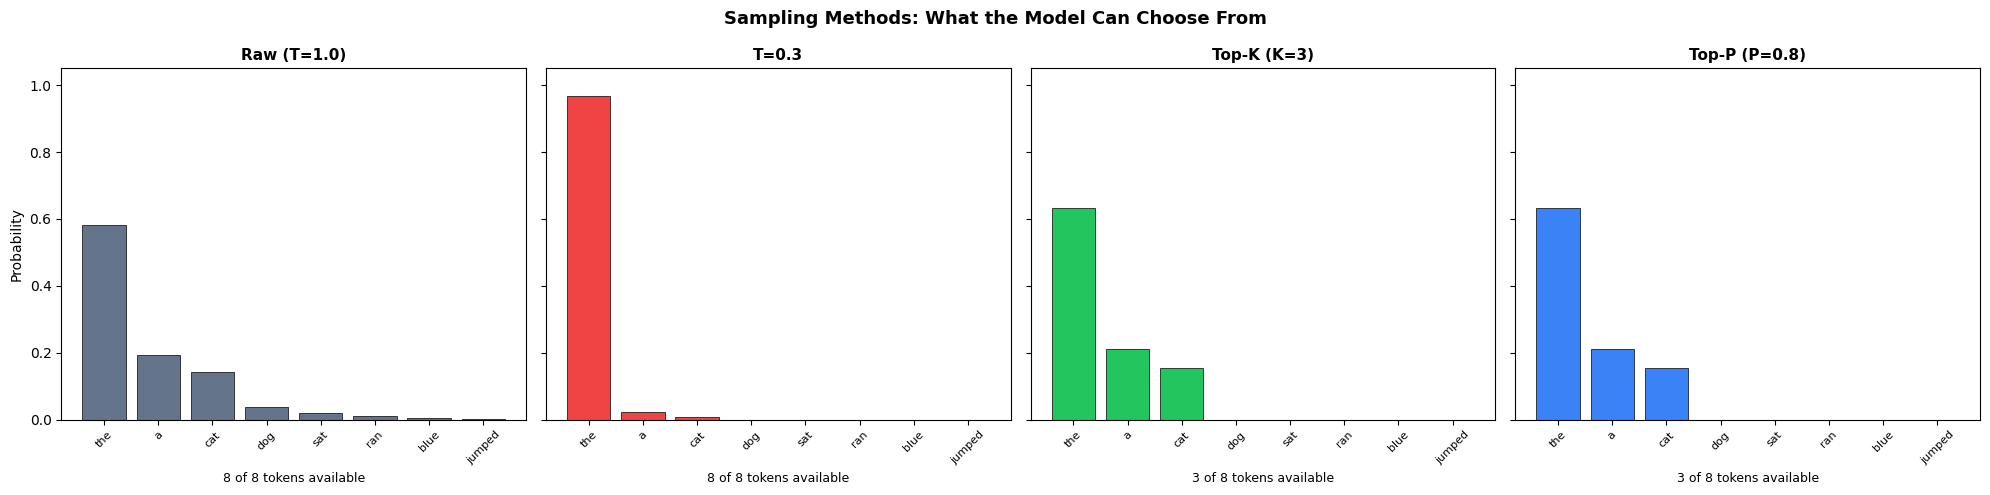

Saved: sampling_methods_comparison.png


In [8]:
# === Visualise all three sampling methods side by side ===

probs_raw = softmax(logits)

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.suptitle('Sampling Methods: What the Model Can Choose From', fontsize=13, fontweight='bold')

cases = [
    ('Raw (T=1.0)', probs_raw,                                   '#64748b'),
    ('T=0.3',       softmax_with_temperature(logits, 0.3),       '#ef4444'),
    ('Top-K (K=3)', top_k_filter(probs_raw, 3),                  '#22c55e'),
    ('Top-P (P=0.8)', top_p_filter(probs_raw, 0.8),              '#3b82f6'),
]

for ax, (title, probs_case, color) in zip(axes, cases):
    # Highlight included tokens differently from excluded ones
    bar_colors = [color if p > 0 else '#e2e8f0' for p in probs_case]
    ax.bar(tokens, probs_case, color=bar_colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    if ax == axes[0]:
        ax.set_ylabel('Probability', fontsize=10)
    
    included = sum(1 for p in probs_case if p > 0)
    ax.set_xlabel(f'{included} of {len(tokens)} tokens available', fontsize=9)

plt.tight_layout()
plt.savefig('sampling_methods_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: sampling_methods_comparison.png")

---
## SECTION 2 — GUIDED BUILD
### Implement the three sampling functions from scratch

> **Instructions:** Fill in every `___` placeholder. The structure is correct — fill in the logic.  
> After filling in each function, a test block runs automatically.

In [9]:
import numpy as np

# Copy softmax from Section 1 so this cell is self-contained
def softmax(logits):
    logits_stable = logits - np.max(logits)
    exp_logits = np.exp(logits_stable)
    return exp_logits / exp_logits.sum()


# === TODO 1: Implement apply_temperature() ===
#
# This function takes raw logits and a temperature value,
# and returns a probability distribution.
#
# Steps:
#   1. Divide the logits by the temperature
#   2. Apply softmax to the scaled logits
#   3. Return the result
#
# EDGE CASE: if temperature is 0, return a one-hot distribution
#            (all probability on the highest-logit token — greedy)

def apply_temperature(logits, temperature):
    """Scale logits by temperature and convert to probabilities.
    
    Args:
        logits:      numpy array of raw logit scores (any range)
        temperature: float > 0 (or exactly 0 for greedy)
    
    Returns:
        numpy array of probabilities summing to 1.
    """
    # Edge case: temperature = 0 means always pick the best token (greedy)
    if temperature == 0:
        # One-hot: 1.0 at the argmax position, 0.0 everywhere else
        one_hot = np.zeros(len(logits))
        one_hot[np.argmax(logits)] = 1.0
        return one_hot
    
    # Step 1: Divide logits by temperature
    # HINT: numpy supports dividing an array by a scalar directly
    scaled_logits = ___ / ___  # TODO: logits divided by temperature
    
    # Step 2: Apply softmax to the scaled logits
    probs = ___(scaled_logits)  # TODO: call the softmax function
    
    return probs


# --- Test ---
test_logits = np.array([4.2, 3.1, 2.8, 1.5, 0.9, 0.3, -0.5, -1.2])
test_tokens = ['the', 'a', 'cat', 'dog', 'sat', 'ran', 'blue', 'jumped']

print("=== Testing apply_temperature() ===")
for T in [0.0, 0.3, 1.0, 2.0]:
    probs = apply_temperature(test_logits, T)
    best_token = test_tokens[np.argmax(probs)]
    print(f"T={T:.1f}: best='{best_token}' ({np.max(probs):.4f}), sum={probs.sum():.6f}")

print()
print("If sum ≈ 1.0 for all rows, your implementation is correct.")

=== Testing apply_temperature() ===
T=0.0: best='the' (1.0000), sum=1.000000


TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [ ]:
# === TODO 2: Implement top_k_filter() ===
#
# Keep only the K tokens with the highest probability.
# Zero out everything else. Re-normalise.
#
# HINT: np.argsort(probs) returns indices sorted in ASCENDING order.
#       To get the HIGHEST k, take the LAST k elements: [-k:]

def top_k_filter(probs, k):
    """Keep only the top-K most probable tokens.
    
    Args:
        probs: numpy array of probabilities summing to 1
        k:     number of tokens to keep (1 = greedy, len(probs) = no filtering)
    
    Returns:
        numpy array — only top-K have non-zero probability, re-normalised.
    """
    # Guard: k can't be larger than the vocabulary
    k = min(k, len(probs))
    
    # Step 1: Find the indices of the K highest-probability tokens
    # np.argsort sorts ascending → the LAST k elements are the TOP k
    top_k_indices = np.argsort(probs)[___]  # TODO: slice to get last k elements
    
    # Step 2: Build a boolean mask (True = keep, False = zero out)
    mask = np.zeros(len(probs), dtype=bool)   # start: all False
    mask[___] = True                           # TODO: set top_k_indices positions to True
    
    # Step 3: Apply the mask — zero out everything NOT in the top K
    filtered = probs.copy()
    filtered[___] = 0.0   # TODO: use ~mask to index the non-top-K positions
    
    # Step 4: Re-normalise (so the remaining probabilities sum to 1)
    if filtered.sum() > 0:
        filtered = filtered / ___  # TODO: divide by the total of remaining probabilities
    
    return filtered


# --- Test ---
probs_test = apply_temperature(test_logits, temperature=1.0)

print("=== Testing top_k_filter() ===")
print()
for k in [1, 2, 3, 8]:
    filtered = top_k_filter(probs_test, k)
    non_zero = [(test_tokens[i], round(filtered[i], 4)) for i in range(len(test_tokens)) if filtered[i] > 0]
    print(f"K={k}: {non_zero}")

print()
print("If K=8 includes all tokens with probabilities matching original, it's correct.")

In [ ]:
# === TODO 3: Implement top_p_filter() ===
#
# Keep the smallest set of tokens whose probabilities sum to at least p.
# Zero out the rest. Re-normalise.
#
# HINT: np.argsort(probs)[::-1] gives indices sorted by HIGHEST probability first.
#       np.cumsum() computes a running sum.

def top_p_filter(probs, p):
    """Keep only tokens in the top-P nucleus.
    
    Args:
        probs: numpy array of probabilities summing to 1
        p:     cumulative probability threshold (0 < p <= 1)
    
    Returns:
        numpy array — only nucleus tokens have non-zero probability, re-normalised.
    """
    # Step 1: Sort token indices by probability, HIGHEST first
    # np.argsort is ascending, [::-1] reverses it to descending
    sorted_indices = np.argsort(probs)___  # TODO: reverse the sort order
    
    # Step 2: Get the sorted probabilities (in the same descending order)
    sorted_probs = probs[___]  # TODO: index probs with sorted_indices
    
    # Step 3: Compute the cumulative sum
    # After this: cumulative[i] = sum of the i+1 highest probabilities
    cumulative = np.___( sorted_probs )  # TODO: use the right numpy function
    
    # Step 4: Find how many tokens we need to reach cumulative probability p
    # np.searchsorted(arr, val) returns the index where val would be inserted
    # to keep arr sorted — i.e., the first index where arr[idx] >= val
    cutoff_idx = np.searchsorted(cumulative, p) + 1  # +1 to include the crossing token
    cutoff_idx = min(cutoff_idx, len(probs))          # don't go out of bounds
    
    # Step 5: Keep only the nucleus tokens
    nucleus_indices = sorted_indices[___]  # TODO: slice to get first cutoff_idx elements
    
    mask = np.zeros(len(probs), dtype=bool)
    mask[nucleus_indices] = True
    
    filtered = probs.copy()
    filtered[~mask] = 0.0
    
    # Step 6: Re-normalise
    if filtered.sum() > 0:
        filtered = filtered / filtered.sum()
    
    return filtered


# --- Test ---
probs_test = apply_temperature(test_logits, temperature=1.0)

print("=== Testing top_p_filter() ===")
print()
for p_val in [0.5, 0.7, 0.9, 1.0]:
    filtered = top_p_filter(probs_test, p_val)
    non_zero = [(test_tokens[i], round(filtered[i], 4)) for i in range(len(test_tokens)) if filtered[i] > 0]
    print(f"P={p_val}: nucleus size={len(non_zero)} → {non_zero}")

print()
print("If the nucleus grows as P increases, your implementation is correct.")

---
## SECTION 3 — EXPERIMENT
### Use the Gemini API to observe temperature and sampling in action

Everything in Section 1 and 2 was theory on a toy vocabulary.  
Now we run real LLM calls and observe how the output changes with different parameter settings.

In [ ]:
import google.generativeai as genai
import os

# Configure the Gemini client with our API key
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY', '')

if not GEMINI_API_KEY:
    print("No GEMINI_API_KEY found — skipping live API experiments.")
    print("The concepts from Sections 1–2 fully demonstrate the math.")
    SKIP_API = True
else:
    genai.configure(api_key=GEMINI_API_KEY)  # tell the library to use this key
    print("Gemini API configured successfully.")
    SKIP_API = False

In [ ]:
# === Experiment 3.1 — Temperature effect on creative writing ===
# Same prompt, same model, only temperature changes
# Run this cell 3 times and observe if low-T outputs are consistent while high-T varies

if SKIP_API:
    print("Skipping — no API key. See Section 1 plots for the same concept.")
else:
    def call_gemini(prompt, temperature, max_output_tokens=150):
        """Call Gemini API with specific generation parameters."""
        model = genai.GenerativeModel('gemini-1.5-flash')  # fast, free-tier model
        
        # GenerationConfig controls the sampling parameters
        config = genai.GenerationConfig(
            temperature=temperature,          # controls randomness
            max_output_tokens=max_output_tokens,  # stop after N tokens
        )
        
        response = model.generate_content(prompt, generation_config=config)
        return response.text
    
    
    # The prompt — a creative writing opener
    creative_prompt = "Continue this story in exactly 2 sentences: The astronaut opened the hatch and saw"
    
    temperatures = [0.1, 0.7, 1.2]
    
    print("=== Effect of temperature on creative writing ===")
    print(f"Prompt: '{creative_prompt}'")
    print()
    
    for T in temperatures:
        print(f"--- Temperature = {T} ---")
        output = call_gemini(creative_prompt, temperature=T)
        print(output)
        print()

In [ ]:
# === Experiment 3.2 — Temperature effect on factual questions ===
# Low temperature → consistent, reliable answers
# High temperature → creative but potentially wrong answers

if SKIP_API:
    print("Skipping — no API key.")
else:
    factual_prompt = "What is the capital city of France? Answer in one sentence."
    
    print("=== Effect of temperature on factual questions ===")
    print(f"Prompt: '{factual_prompt}'")
    print()
    print("Running each temperature 3 times to show consistency vs variance:")
    print()
    
    for T in [0.1, 1.5]:
        print(f"--- Temperature = {T} (3 runs) ---")
        for run in range(3):
            output = call_gemini(factual_prompt, temperature=T, max_output_tokens=50)
            print(f"  Run {run+1}: {output.strip()}")
        print()
    
    print("KEY INSIGHT:")
    print("  Low temperature → same answer every time (deterministic)")
    print("  High temperature → different phrasing each time (stochastic)")
    print("  For factual tasks, always use low temperature (0.1–0.3)")
    print("  For creative tasks, use high temperature (0.7–1.2)")

In [ ]:
# === Experiment 3.3 — Top-K and Top-P with Gemini ===
# Gemini's GenerationConfig supports top_k and top_p directly

if SKIP_API:
    print("Skipping — no API key.")
else:
    def call_gemini_full(prompt, temperature=1.0, top_k=None, top_p=None, max_output_tokens=100):
        """Call Gemini with full sampling parameter control."""
        model = genai.GenerativeModel('gemini-1.5-flash')
        
        # Build the config — only pass parameters that are specified
        config_kwargs = {
            'temperature': temperature,
            'max_output_tokens': max_output_tokens,
        }
        if top_k is not None:
            config_kwargs['top_k'] = top_k   # top-K sampling
        if top_p is not None:
            config_kwargs['top_p'] = top_p   # top-P (nucleus) sampling
        
        config = genai.GenerationConfig(**config_kwargs)
        response = model.generate_content(prompt, generation_config=config)
        return response.text
    
    
    poem_prompt = "Write the opening line of a poem about the ocean:"
    
    print("=== Comparing sampling strategies ===")
    print(f"Prompt: '{poem_prompt}'")
    print()
    
    experiments = [
        {'label': 'Greedy (T=0.1, no filtering)',   'temperature': 0.1},
        {'label': 'Standard (T=0.7)',               'temperature': 0.7},
        {'label': 'Top-K=5, T=0.7',                'temperature': 0.7, 'top_k': 5},
        {'label': 'Top-P=0.5, T=0.7',              'temperature': 0.7, 'top_p': 0.5},
        {'label': 'Creative (T=1.2)',               'temperature': 1.2},
    ]
    
    for exp in experiments:
        label = exp.pop('label')
        output = call_gemini_full(poem_prompt, **exp)
        print(f"[{label}]")
        print(f"  {output.strip()[:200]}")
        print()

---
## SECTION 4 — CHALLENGE
### Build a complete `sample_token()` function

You now have all three building blocks:
- `apply_temperature()` — adjusts the probability distribution
- `top_k_filter()` — narrows to the K most likely tokens
- `top_p_filter()` — narrows to the nucleus

The challenge: combine them in the **correct order** into a single `sample_token()` function.

**Correct order:** temperature → top-K → top-P → sample

> This is not arbitrary. Temperature rescales the entire distribution first. Then top-K/top-P filter the already-rescaled distribution. Applying top-K before temperature would filter on unscaled logits, which changes which tokens are included.

In [ ]:
import numpy as np

# Copy helpers — all three functions must be defined before sample_token()
def softmax(logits):
    logits_stable = logits - np.max(logits)
    exp_logits = np.exp(logits_stable)
    return exp_logits / exp_logits.sum()

# (Paste your implementations of apply_temperature, top_k_filter, top_p_filter here
#  if this cell is run independently. They are already defined in cells above.)


# === CHALLENGE: implement sample_token() ===
#
# This function:
#   1. Applies temperature to the logits
#   2. Optionally applies top-K filtering
#   3. Optionally applies top-P filtering
#   4. Samples one token index from the resulting distribution
#   5. Returns the sampled index
#
# IMPORTANT: do NOT change the order of steps 1 → 2 → 3 → 4

def sample_token(logits, temperature=1.0, top_k=None, top_p=None):
    """Sample one token from logits using temperature + top-K + top-P.
    
    Args:
        logits:      numpy array of raw logit scores (one per token in vocab)
        temperature: float > 0. Default 1.0 (no change).
        top_k:       int or None. If set, only sample from top-K tokens.
        top_p:       float or None. If set, only sample from nucleus tokens.
    
    Returns:
        int: the index of the sampled token
    """
    # TODO Step 1: Apply temperature to convert logits → probabilities
    # HINT: call apply_temperature(logits, temperature)
    probs = ___
    
    # TODO Step 2: Apply top-K filtering (only if top_k is not None)
    # HINT: use an if statement to check `if top_k is not None:`
    if top_k is not None:
        probs = ___(probs, top_k)   # TODO: call top_k_filter with right args
    
    # TODO Step 3: Apply top-P filtering (only if top_p is not None)
    if top_p is not None:
        probs = ___(probs, top_p)   # TODO: call top_p_filter with right args
    
    # TODO Step 4: Sample one token index from the probability distribution
    # np.random.choice(n, p=probs) samples an integer from 0..n-1
    # with the probabilities given by probs
    sampled_index = np.random.choice(___, p=___)  # TODO: fill in n and p
    
    return sampled_index


# --- Test ---
logits_test = np.array([4.2, 3.1, 2.8, 1.5, 0.9, 0.3, -0.5, -1.2])
vocab_test  = ['the', 'a', 'cat', 'dog', 'sat', 'ran', 'blue', 'jumped']

print("=== Testing sample_token() ===")
print()

configs = [
    {'temperature': 0.1},
    {'temperature': 1.0},
    {'temperature': 1.5},
    {'temperature': 1.0, 'top_k': 3},
    {'temperature': 1.0, 'top_p': 0.8},
    {'temperature': 0.8, 'top_k': 4, 'top_p': 0.9},  # all three combined
]

for config in configs:
    # Sample 10 tokens with this config to see the distribution
    samples = [vocab_test[sample_token(logits_test, **config)] for _ in range(10)]
    label = ', '.join(f"{k}={v}" for k, v in config.items())
    print(f"[{label}]")
    print(f"  10 samples: {samples}")
    print()

In [ ]:
# === EXTENSION: Build a tiny text generator using sample_token() ===
#
# We'll simulate a tiny language model with a fixed 3-token vocabulary
# and manually defined transition probabilities (no training needed)
#
# Each token has a fixed set of logits for "what comes next"
# This simulates how a real LLM works token by token

vocab = ['cat', 'sat', 'mat']

# Transition table: given the last token, what are the logits for the next token?
# This encodes simple grammar: cat → likes to sit, mat → tends to come after sat
transition_logits = {
    'cat':  np.array([1.0,  3.5, -0.5]),   # after 'cat': most likely 'sat'
    'sat':  np.array([-0.5, 1.0,  4.0]),   # after 'sat': most likely 'mat'
    'mat':  np.array([3.0, -0.5,  1.0]),   # after 'mat': most likely 'cat'
    None:   np.array([4.0,  0.5,  0.5]),   # start of sequence: begin with 'cat'
}

def generate_sequence(length, temperature=1.0, top_k=None, top_p=None):
    """Generate a token sequence using our sample_token() function."""
    sequence = []
    last_token = None  # start of sequence
    
    for _ in range(length):
        # Get the logits for what comes after the last token
        logits = transition_logits[last_token]
        
        # Sample the next token index
        next_idx = sample_token(logits, temperature=temperature, top_k=top_k, top_p=top_p)
        next_token = vocab[next_idx]
        
        sequence.append(next_token)
        last_token = next_token
    
    return ' '.join(sequence)


print("=== Tiny text generator using your sample_token() ===")
print()

gen_configs = [
    ('Greedy  (T=0.01)',               {'temperature': 0.01}),
    ('Normal  (T=0.7)',                {'temperature': 0.7}),
    ('Random  (T=2.0)',                {'temperature': 2.0}),
    ('Top-K=2, T=0.7',                {'temperature': 0.7, 'top_k': 2}),
    ('Top-P=0.7, T=0.7',              {'temperature': 0.7, 'top_p': 0.7}),
]

for label, config in gen_configs:
    outputs = [generate_sequence(6, **config) for _ in range(3)]
    print(f"[{label}]")
    for o in outputs:
        print(f"  {o}")
    print()

print("OBSERVATION:")
print("  Greedy: always the same sequence (cat sat mat cat sat mat ...)")
print("  High temperature: breaks the pattern — may generate unusual continuations")
print("  Top-K=2: forces variety but only within the 2 most likely tokens at each step")

---
## Session Wrap-Up

### What you built
- `apply_temperature()` — from logits to a temperature-adjusted probability distribution
- `top_k_filter()` — hard cutoff at K most likely tokens
- `top_p_filter()` — adaptive nucleus sampling
- `sample_token()` — the complete sampling pipeline (correct order: T → K → P → sample)
- A tiny text generator demonstrating the pipeline token-by-token

### Key takeaways
1. **The model doesn't 'decide' the next word — it computes a distribution and samples from it**
2. **Temperature controls sharpness** — low T for facts, high T for creativity
3. **Top-K is simple but fixed** — the right K depends on context
4. **Top-P is adaptive** — nucleus expands when the model is uncertain, shrinks when confident
5. **Order matters:** temperature first, then top-K, then top-P, then sample
6. **These parameters are in every API you will ever call** — you now understand what they actually do

### Practical defaults
| Task | Temperature | Top-K | Top-P |
|---|---|---|---|
| Factual Q&A | 0.1–0.3 | 1–5 | 0.5–0.7 |
| Code generation | 0.2–0.4 | 10–20 | 0.8 |
| Creative writing | 0.8–1.2 | 40–50 | 0.9–0.95 |
| Brainstorming | 1.0–1.5 | 50 | 0.95 |

### What's next
**S05** will cover **prompt engineering** — now that you understand how the model picks words, you can use that knowledge to write prompts that guide it more effectively.

---
*Part of the GenAI-2026 curriculum — zero-to-genai-engineer track*